In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("unemployement.csv")

In [4]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [5]:
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [8]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [9]:
df.duplicated().sum()

np.int64(27)

In [10]:
df= df.drop_duplicates()

In [11]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

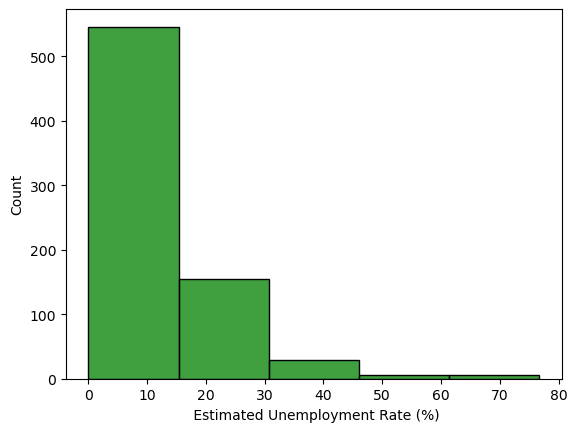

In [12]:
#lets do EDA 
#HOW IS UNEMPLOYEMENT DISTRIBUTED
sns.histplot(df[' Estimated Unemployment Rate (%)'],bins=5, color="green",)
plt.show()
             

In [15]:
df[' Date'] = pd.to_datetime(df[' Date'])

In [16]:
df['Year'] = df[' Date'].dt.year

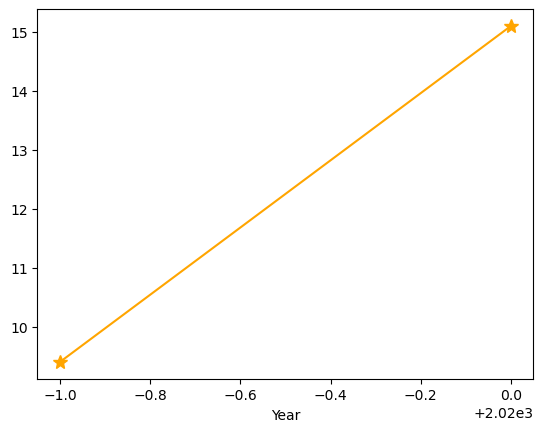

In [17]:
yearly = df.groupby('Year')[' Estimated Unemployment Rate (%)'].mean()

yearly.plot(marker='*',color="orange",markersize=10)
plt.show()

In [18]:
corr = df.corr(numeric_only=True)

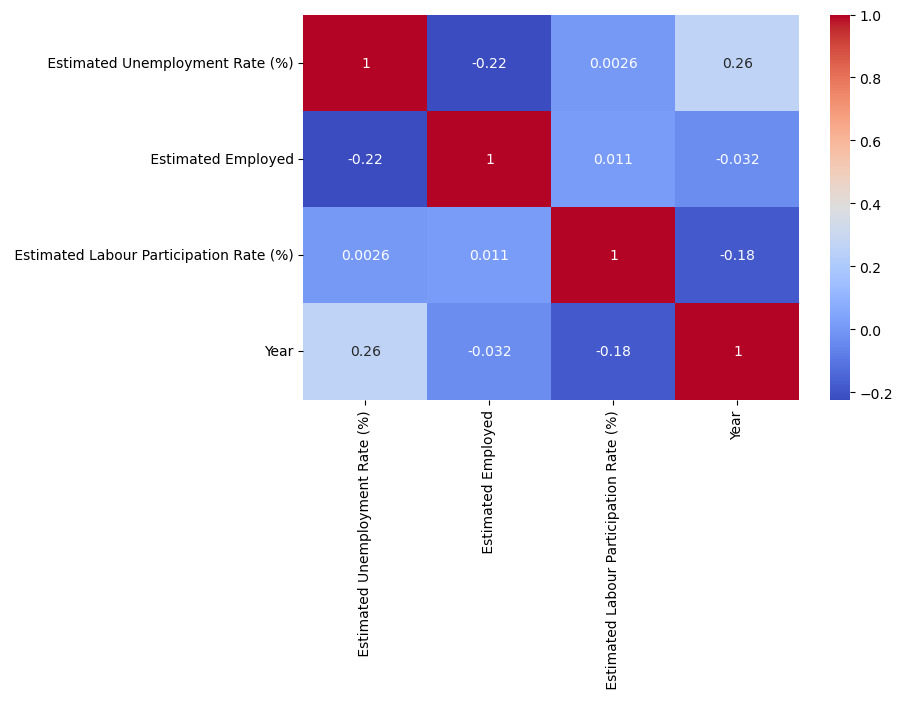

In [19]:
plt.figure(figsize=(8,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [20]:
df.columns = df.columns.str.strip()

In [22]:
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area',
       'Year', 'Month'],
      dtype='object')

In [23]:
df["Month"] = df["Date"].dt.month_name()

In [24]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year,Month
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019.0,May
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019.0,June
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019.0,July
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019.0,August
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019.0,September


C:\Users\ragha\AppData\Local\Temp\ipykernel_48216\3665099727.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


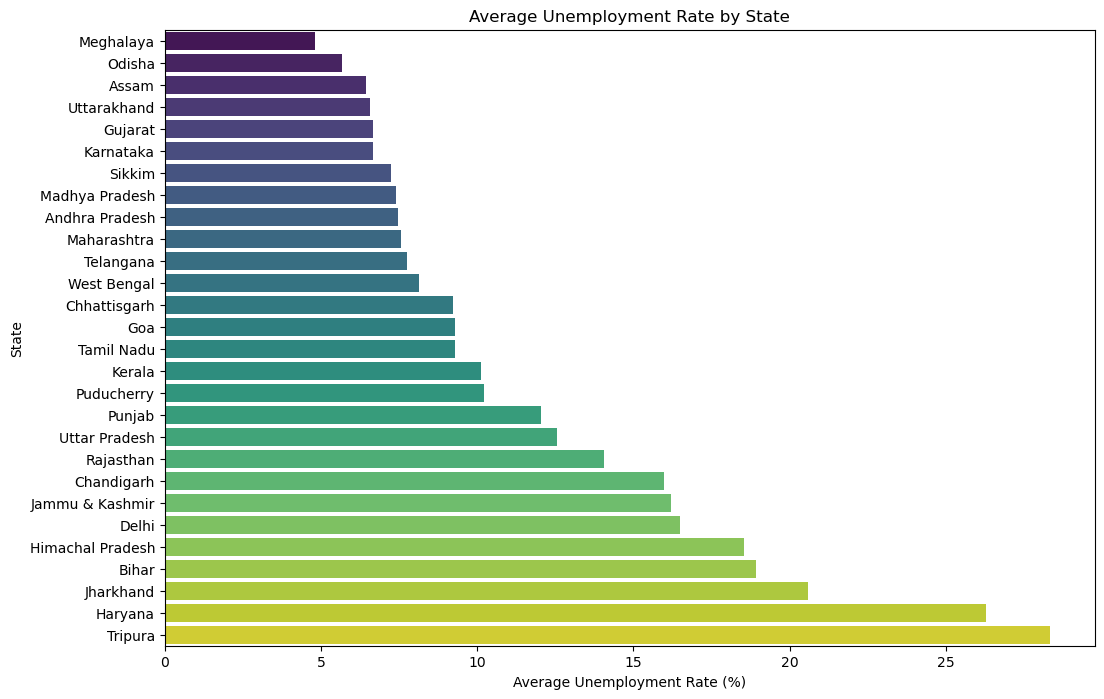

In [25]:
#average unemployement from state
plt.figure(figsize=(12,8))

state = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values()

sns.barplot(
    x=state.values,
    y=state.index,
    palette="viridis"
)

plt.title("Average Unemployment Rate by State")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")

plt.show()

C:\Users\ragha\AppData\Local\Temp\ipykernel_48216\3539470841.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


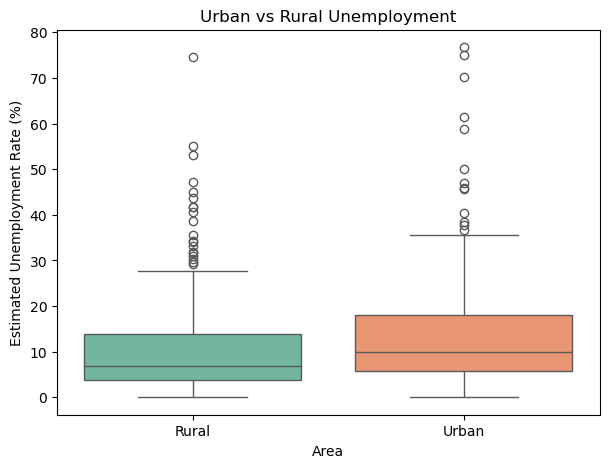

In [26]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="Area",
    y="Estimated Unemployment Rate (%)",
    data=df,
    palette="Set2"
)

plt.title("Urban vs Rural Unemployment")

plt.show()

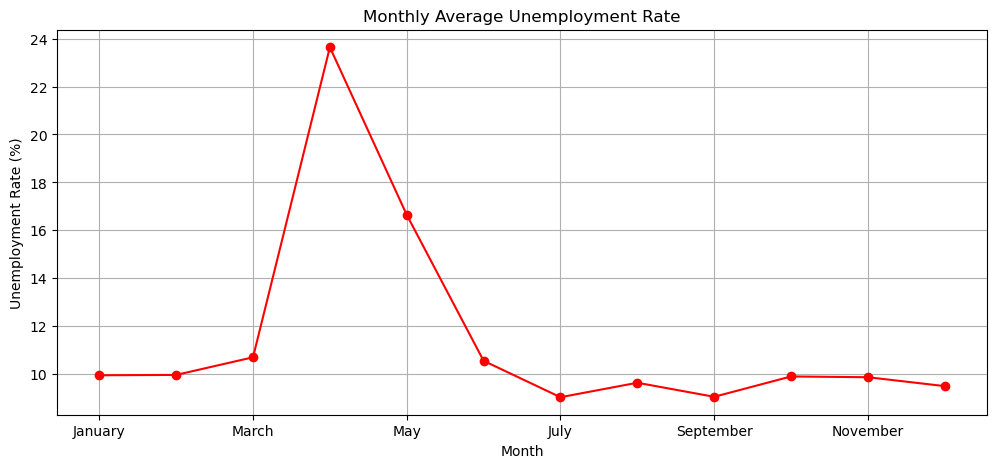

In [27]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly = df.groupby("Month")["Estimated Unemployment Rate (%)"].mean()

monthly = monthly.reindex(month_order)

plt.figure(figsize=(12,5))

monthly.plot(marker="o",color="red")

plt.title("Monthly Average Unemployment Rate")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)

plt.show()

The monthly analysis reveals fluctuations in unemployment throughout the year. Some months record higher unemployment than others, indicating possible seasonal variations in economic activity and employment opportunities.

In [28]:
#covid-19 impact analysis
before = df[df["Date"] < "2020-03-01"]

after = df[df["Date"] >= "2020-03-01"]

In [29]:
print("Before Covid:",before["Estimated Unemployment Rate (%)"].mean())

print("After Covid:",after["Estimated Unemployment Rate (%)"].mean())

Before Covid: 9.509533582089553
After Covid: 17.774362745098042


C:\Users\ragha\AppData\Local\Temp\ipykernel_48216\1133400723.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


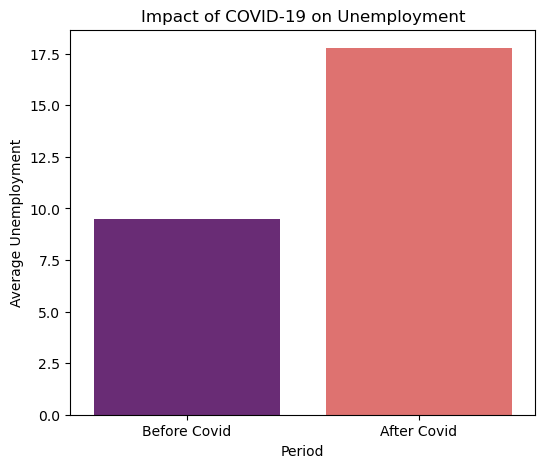

In [30]:
covid = pd.DataFrame({

    "Period":["Before Covid","After Covid"],

    "Average Unemployment":[
        before["Estimated Unemployment Rate (%)"].mean(),
        after["Estimated Unemployment Rate (%)"].mean()
    ]

})

plt.figure(figsize=(6,5))

sns.barplot(
    data=covid,
    x="Period",
    y="Average Unemployment",
    palette="magma"
)

plt.title("Impact of COVID-19 on Unemployment")

plt.show()

The unemployment rate increased significantly after the onset of COVID-19 in 2020. Lockdowns, business closures, and economic disruptions contributed to a sudden rise in unemployment across many regions of India.

In [31]:
#highest unemployemnt state
highest = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean()

highest = highest.sort_values(ascending=False)

highest.head(10)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64

In [32]:
#lowest unemployment state
lowest = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean()

lowest = lowest.sort_values()

lowest.head(10)

Region
Meghalaya         4.798889
Odisha            5.657857
Assam             6.428077
Uttarakhand       6.582963
Gujarat           6.663929
Karnataka         6.676071
Sikkim            7.249412
Madhya Pradesh    7.406429
Andhra Pradesh    7.477143
Maharashtra       7.557500
Name: Estimated Unemployment Rate (%), dtype: float64

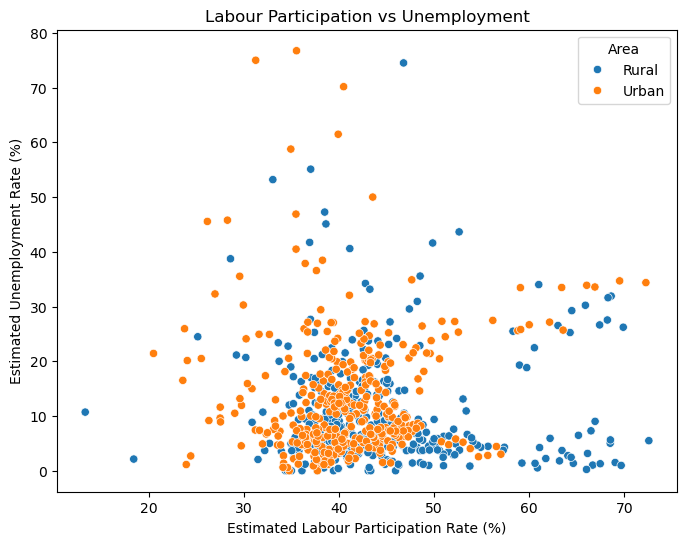

In [33]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Estimated Labour Participation Rate (%)",
    y="Estimated Unemployment Rate (%)",
    hue="Area"
)

plt.title("Labour Participation vs Unemployment")

plt.show()

## Insights

The unemployment rate varies considerably across states.

The COVID-19 period shows a noticeable increase in unemployment.

Urban and rural areas display different unemployment characteristics.

Employment and labour participation are related to unemployment trends.

Monthly observations indicate seasonal fluctuations in unemployment.

## Policy Recommendations

Strengthen employment programs during economic crises.

Support small and medium enterprises to protect jobs.

Increase investment in skill development and digital training.

Expand rural employment opportunities and infrastructure projects.

Provide better social security and unemployment assistance for vulnerable workers.

## CONCLUSIONS

This project analyzed unemployment data in India using Python. The dataset was cleaned and explored through descriptive statistics and visualizations. The analysis showed significant regional differences in unemployment and highlighted the sharp increase in unemployment during the COVID-19 period. Monthly trends suggested seasonal fluctuations, and the findings emphasize the need for effective employment policies, skill development initiatives, and economic support during crises.